Write your solution in here.

- Your code has to reference all data files using **relative** paths so that they can be loaded on other computers without modifications.
- All data files need to be stored in the `data/` folder.

For example: (REMOVE THIS)

In [225]:
import pandas as pd

# Define the path to the data directory
DATA_PATH = './data'

# Read the CSV using a relative path
df = pd.read_csv(f'{DATA_PATH}/sce_extract_2015.csv')

# Term Paper 2 - Expectations about Macroeconomic and Financial Variables

### Initial Setup - Modules, Display options, Data Path

In [226]:
# Modules
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
# Scikit-learn modules for regression and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder

# Set display options for better readability
pd.set_option('display.max_columns', 50)

# Define the path to the data directory
DATA_PATH = './data'

## Part 1 - Data Preprocessing (SCE)

In [227]:
# Step 1 - Import and merge SCE data from all waves, keeping only relevant columns and parsing dates

# Variables with large share of NAs where dropped before implementing final solution

# Variables asked only at the first interview → need forward-filling
COLS_FIRST_WAVE = [
    'owner',
    'num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct',
    'num_lit_q5_correct', 'num_lit_q6_correct'
]

# Variables related to expectations → need outlier treatment
COLS_EXPECTATIONS = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']

# Define titles for the expectation variable plots
titles = [
    'Expected Inflation (1-year ahead, %)',
    'Expected House Price Change (%)',
    'Probability Unemployment Goes Up (%)',
    'Probability Stocks Go Up (%)'
]

# Create a list of (column, title) pairs for plotting
exp_plot_vars = list(zip(COLS_EXPECTATIONS, titles))

# Variables related to individual characteristics → no cleaning needed
COLS_INDIVIDUAL = [
    'female', 'hispanic', 'black', 'educ',
    'hh_inc_bin_rank', 'working', 'couple', 'num_kids', 'age_init'
]

# Variables to keep for analysis (expectations + first-wave + individual characteristics)
ANALYSIS_COLS = COLS_EXPECTATIONS + COLS_FIRST_WAVE + COLS_INDIVIDUAL

# Metadata columns to keep for merging and panel structure (Weight dropped - not needed for analysis, not compatible with all scikit-learn methods)
COLS_META = ['userid', 'wid', 'date', 'tenure']

# All variables to read from the CSV files (Defined before reading files to avoid reading unnecessary columns)
ALL_COLS  = COLS_META + ANALYSIS_COLS

# Read and concatenate all CSV files, keeping only the relevant columns and parsing dates
files = sorted(glob.glob(f'{DATA_PATH}/sce_extract_*.csv'))

sce = pd.concat(
    [pd.read_csv(f, usecols=lambda c: c in ALL_COLS, parse_dates=['date']) for f in files],
    ignore_index=True
).sort_values(['userid', 'date']).reset_index(drop=True)

# Verify that all expected columns are present
assert set(ALL_COLS).issubset(sce.columns), (
    f"Missing columns: {set(ALL_COLS) - set(sce.columns)}"
)

# Initial data summary
n_obs_init   = len(sce)
n_ind_init   = sce['userid'].nunique()
n_waves_init = sce['wid'].nunique()

first_date_init = sce['date'].min().date()
last_date_init  = sce['date'].max().date()

print("=== Initial sample ===")
print(f"  Observations : {n_obs_init:,}")
print(f"  Individuals  : {n_ind_init:,}")
print(f"  Survey waves : {n_waves_init}")
print(f"  Date range   : {first_date_init} → {last_date_init}")

=== Initial sample ===
  Observations : 180,268
  Individuals  : 23,886
  Survey waves : 143
  Date range   : 2013-06-01 → 2025-05-01


The individual-level features were selected based on two criteria: economic relevance as predictors of expectations, and data availability. Several variables were excluded due to a high share of missing values (20% or more), which would have substantially reduced the sample size: num_lit_q8_correct, num_lit_q9_correct, take_fin_risk, health, and self_employed. The survey sampling weight was dropped since not all scikit-learn estimators support sample weights.
Variables asked only at the first interview (owner, age_init, and the numerical literacy indicators) are forward-filled within each individual so that later waves carry the value from the first wave. Other expectation-related variables (e.g. infl_3y, prob_irate_up) are excluded as predictors, since they would not be available to a policymaker trying to forecast expectations in real time.

age_init was recorded at first interview, but carried forward prior to our analysis, hence why it's not in COLS_FIRST_WAVE. 

In [228]:
# Step 2 - Forward-fill within each individual (only fills NaNs after the first observed value)
sce[COLS_FIRST_WAVE] = (
    sce.groupby('userid')[COLS_FIRST_WAVE].ffill()
)

In [229]:
# Step 3 - Drop observations from 2025 due to Trump-volatility
mask_2025 = sce['date'].dt.year == 2025
n_dropped_2025 = mask_2025.sum()
sce = sce[~mask_2025].copy()
print(f"Step 3 — Dropped {n_dropped_2025:,} observations from 2025")

Step 3 — Dropped 4,167 observations from 2025


In [230]:
# Step 4 - Drop observations with missing values in the analysis columns
n_before = len(sce)
sce = sce.dropna(subset=ANALYSIS_COLS).copy()
print(f"Step 4 — Dropped {n_before - len(sce):,} observations with missing values")

Step 4 — Dropped 16,966 observations with missing values


In [231]:
print((sce['prob_unrate_up'] == 0).sum())
print((sce['prob_unrate_up'] == 100).sum())

2679
1855


In [232]:
# Step 5 - Trimming outliers
# Compute all percentiles upfront
percentiles = {col: (sce[col].quantile(0.01), sce[col].quantile(0.99)) for col in COLS_EXPECTATIONS}
obs_dropped_outliers = 0

for col in COLS_EXPECTATIONS:
    p1, p99 = percentiles[col]
    n_before = len(sce)
    sce = sce[(sce[col] > p1) & (sce[col] < p99)]
    print(f"  {col}: P1={p1:.2f}, P99={p99:.2f} → dropped {n_before - len(sce):,} obs")
    obs_dropped_outliers += n_before - len(sce)

# Reset index
sce = sce.reset_index(drop=True)

print('-' * 60)
print(f"Step 5 — Dropped a total of {obs_dropped_outliers:,} observations as outliers")

  infl_1y: P1=-30.00, P99=60.00 → dropped 3,400 obs
  house_price_change: P1=-20.00, P99=50.00 → dropped 3,790 obs
  prob_unrate_up: P1=0.00, P99=100.00 → dropped 4,034 obs
  prob_stocks_up: P1=0.00, P99=95.00 → dropped 2,394 obs
------------------------------------------------------------
Step 5 — Dropped a total of 13,618 observations as outliers


For prob_unrate_up, the 1st percentile is 0 and the 99th percentile is 100. Since the trimming condition is strictly > P1 and < P99, observations with values exactly equal to 0 or 100 are dropped. These are respondents who are completely certain about the direction of unemployment, which are valid responses rather than data errors - however, we follow the assignment instructions and apply the same rule to all four variables.
For prob_stocks_up, P99 = 95, meaning the top 1% of responses (above 95%) are removed as extreme outliers.

In [233]:
# Step 6 - Create Optimism indicators
sce['optimist_unrate']      = (sce['prob_unrate_up'] < 50).astype(int)
sce['optimist_stocks']      = (sce['prob_stocks_up'] > 50).astype(int)
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)

# Store optimism indicators in a list for later use
OPTIMISM_COLS = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Labels for the optimism indicators
opt_titles = [
    'Unemployment Optimists (prob < 50%)',
    'Stock Market Optimists (prob > 50%)',
    'House Price Optimists (change > 0%)'
]

# Create a list of (column, title) pairs for plotting
opt_plot_vars = list(zip(OPTIMISM_COLS, opt_titles))

In [234]:
# Data cleaning summary
summary = pd.DataFrame({
    'Sample'       : ['Initial', 'Final', 'Difference'],
    'Observations' : [n_obs_init, len(sce), len(sce) - n_obs_init],
    'Individuals'  : [n_ind_init, sce['userid'].nunique(), sce['userid'].nunique() - n_ind_init],
    'Survey waves' : [n_waves_init, sce['wid'].nunique(), sce['wid'].nunique() - n_waves_init],
    'First date'   : [first_date_init, sce['date'].min().date(), 'No Change'],
    'Last date'    : [last_date_init, sce['date'].max().date(), f'{(sce["date"].max().date() - last_date_init).days} days'],
})
display(summary)

,Sample,Observations,Individuals,Survey waves,First date,Last date
0,Initial,180268,23886,143,2013-06-01,2025-05-01
1,Final,145517,21783,139,2013-06-01,2024-12-31
2,Difference,-34751,-2103,-4,No Change,-121 days


The final sample of $145,517$ observations is close to the target of ~$150,000$

## Part 2 - Data Preprocessing (Macro/Finance)

All macro and financial time series are downloaded and saved as CSV files in the "data" folder. **Yahoo Finance** data was downloaded programmatically using yfinance, while **FRED** data was downloaded manually from fred.stlouisfed.org. All series are resampled to monthly frequency. To avoid look-ahead bias, each series is shifted forward by one month so that a respondent interviewed in month $t$ only sees data available through the end of month $t−1$. For quarterly series (GDP, House Price Index), values are forward-filled within the quarter.

Additionally, we added two series not mentioned in the assignment - CBOE Volatility Index (VIX) and US 10-year treasury yield. 
- VIX captures uncertainty directly, which could be relevant for prob_stocks_up and general economic expectations.  
- The 10-year treasury yield as the long end of the yield curve embeds market participants' inflation and growth expectations, making it a good candidate for modelling infl_1y. 

Variables are included both in levels and as changes:

- Levels capture the current macroeconomic environment (e.g., high unemployment may anchor pessimism about future unemployment).
- 12-month changes capture recent momentum and surprises (e.g., a sharp rise in CPI may push inflation expectations higher regardless of the level).
- 1-month changes are computed for monthly series only and capture short-run surprises.
- VIX is kept only in levels since it is already a measure of reltive uncertainty. Percentage changes would be harder to interpret economically. 

For series expressed as index or price levels (CPI, House Price Index, Real GDP, USD Index, WTI Crude Oil, S&P 500), changes are expressed as percentage growth rates, since a one-unit absolute difference is not economically meaningful. For series already expressed in percentage terms (Federal Funds Rate, Unemployment Rate, 30-Year Mortgage Rate), changes are expressed as percentage-point differences, since a relative change (e.g. "the fed funds rate doubled") would be misleading when the level is near zero.
The final selection of which transformations to use as predictors is deferred to Parts 5 and 6, guided by the correlation analysis in Part 4.

In [235]:
# Read and combine Yahoo data (downloaded programmatically and stored in the data directory as CSV files)
wti   = pd.read_csv(f'{DATA_PATH}/wti_crude_oil.csv', parse_dates=['date'], index_col='date')
sp500 = pd.read_csv(f'{DATA_PATH}/sp500.csv', parse_dates=['date'], index_col='date')

# Create a dictionary to hold the raw Yahoo Finance series
yahoo_series = {"wti_crude_oil": wti, "sp500": sp500}

# Initialize an empty list to store the monthly resampled dataframes
yahoo_m = []

# Resample to month-end frequency, compute returns, and shift by one month to avoid look-ahead bias
for col, raw in yahoo_series.items():
    m = raw.resample("ME").last()
    m[f"{col}_chg"]     = m[col].pct_change()
    m[f"{col}_chg_12m"] = m[col].pct_change(12)
    yahoo_m.append(m.shift(1))

# Concatenate all monthly resampled dataframes into a single DataFrame
yahoo_all = pd.concat(yahoo_m, axis=1)

Yahoo Finance series are loaded and merged, with 1-month and 12-month change calculations performed, and observations shifted by a month.

Note that date range is not limited to SCE data at this point, and with the data starting in January 2010 all returns variables have some NA's. After merging with macro and SCE, there will be none. 

In [236]:
# Configuration: name -> (filename, is_quarterly, change_type)
# pct: price/index series — changes as % growth rates
# diff: series already in % terms — changes as percentage-point differences
# None: no change computed for VIX, where levels are more interpretable than changes
FRED_CONFIG = {
    "cpi":              ("CPIAUCSL.csv",     False, "pct"),
    "house_price_idx":  ("USSTHPI.csv",      True,  "pct"),
    "federal_funds":    ("FEDFUNDS.csv",     False, "diff"),
    "unemployment":     ("UNRATE.csv",       False, "diff"),
    "real_gdp":         ("GDPC1.csv",        True,  "pct"),
    "usd_index":        ("DTWEXBGS.csv",     False, "pct"),
    "mortgage_30y":     ("MORTGAGE30US.csv", False, "diff"),
    "10y_yield":        ("DGS10.csv",        False, "diff"),
    "vix":              ("VIXCLS.csv",       False, None),
}

# Initialize an empty dictionary to hold the monthly resampled macro/finance series
macro_m = {}

# Loop through the FRED_CONFIG to read, process, and compute changes for each macro/finance series
for name, (fname, is_quarterly, chg_fn) in FRED_CONFIG.items():
    s = pd.read_csv(
        f"{DATA_PATH}/{fname}",
        parse_dates=[0], index_col=0,
        header=0, names=["date", name],
    )
    # For quarterly series, shift the index to the end of the quarter to align with SCE survey timing
    if is_quarterly:
        s.index = s.index + pd.offsets.QuarterEnd(0)
    # Resample to month-end frequency, taking the last observation in each month (for quarterly series, this will forward-fill the value for the months within the quarter)
    s_m = s.resample("ME").last()

    if is_quarterly:
        s_m = s_m.ffill()

    # Compute changes based on the specified change type
    if chg_fn is not None:
        # Percentage change for price/index series
        if chg_fn == "pct":
            chg12 = s_m[name].pct_change(12, fill_method=None) * 100
            chg1  = s_m[name].pct_change(1,  fill_method=None) * 100
        # Percentage-point difference for series already in % terms
        elif chg_fn == "diff":
            chg12 = s_m[name].diff(12)
            chg1  = s_m[name].diff(1)
        # If no valid change type is specified, raise an error
        else:
            raise ValueError(f"Unknown change type {chg_fn!r} for series {name!r}")
        
        # Add the computed changes to the monthly dataframe with appropriate column names
        s_m[f"{name}_chg12m"] = chg12

        # 1-month change for non-quarterly series only
        if not is_quarterly:
            s_m[f"{name}_chg1m"] = chg1

    macro_m[name] = s_m

# Concatenate all monthly resampled macro/finance series into a single DataFrame
macro_all = (
    pd.concat([s.shift(1) for s in macro_m.values()], axis=1)
      .sort_index()
)

# Limit date range to match the SCE survey period
macro_all = macro_all.loc[
    (macro_all.index >= sce["date"].min()) &
    (macro_all.index <= sce["date"].max())
]

Macro data sets are loaded and merged, with 1-month and 12-month changes calculated for all variables (except VIX).

In [237]:
# Merge Yahoo Finance data into the monthly macro panel
macro_all = macro_all.join(yahoo_all, how="left")
macro_all = macro_all.sort_index()

# Prepare SCE data for merging: create a month-end date key (date_me) that maps each interview date to the corresponding month-end
sce['date_me'] = sce['date'] + pd.offsets.MonthEnd(0)

# Prepare macro_all for merging: reset date index into a column named 'date_me'
macro_for_merge = macro_all.rename_axis('date_me').reset_index()

# Left-join SCE with macro panel, then drop the temporary merge key
sce_data = sce.merge(macro_for_merge, on='date_me', how='left').drop(columns=['date_me'])

# Verify the merge worked correctly
print(f"SCE observations: {len(sce_data):}")
print(f"Macro/Finance panel observations: {len(macro_for_merge):,}")
print(f'Total NA values after final merge: {(sce_data.isna().sum()).sum():,}')
print("\nSample of macro columns for first few rows:")
display(sce_data[['date', 'cpi', 'unemployment', 'sp500', 'wti_crude_oil']].tail())

SCE observations: 145517
Macro/Finance panel observations: 139
Total NA values after final merge: 0

Sample of macro columns for first few rows:


,date,cpi,unemployment,sp500,wti_crude_oil
145512,2024-12-19,316.528,4.2,6032.379883,68.0
145513,2024-12-02,316.528,4.2,6032.379883,68.0
145514,2024-12-20,316.528,4.2,6032.379883,68.0
145515,2024-12-05,316.528,4.2,6032.379883,68.0
145516,2024-12-12,316.528,4.2,6032.379883,68.0


All macroeconomic and finance data merged with SCE, limited to SCE date range and shifted by a month to reflect real time information. 

## Part 3 - Exploratory Data Analysis (SCE)

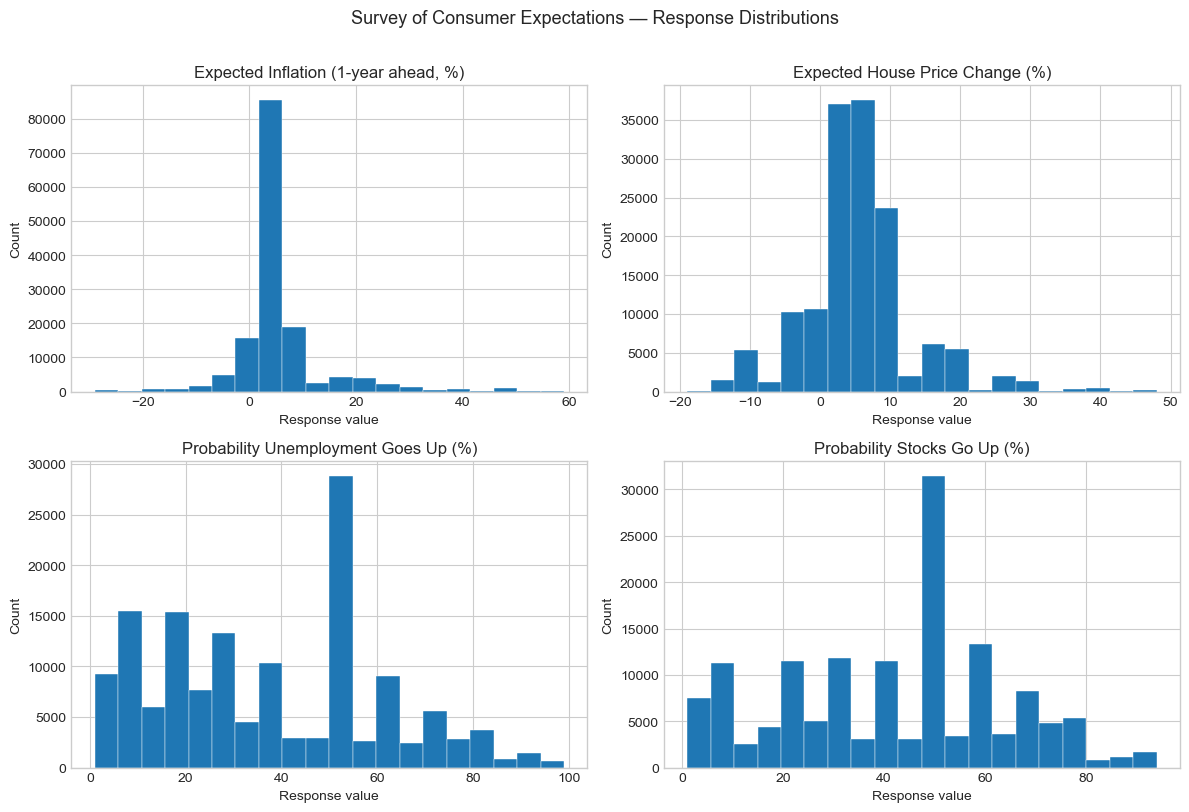

In [238]:
# Step 1 - Histograms of the key expectation variables to visualize their distributions after cleaning
# Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))



# Loop through the variables and create histograms
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.hist(sce_data[col].dropna(), bins=20, edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('Response value')
    ax.set_ylabel('Count')

# Final adjustments and show the plot
fig.suptitle('Survey of Consumer Expectations — Response Distributions', fontsize=13, y=1.01)
_ = plt.tight_layout()

Skriv tekst her (observasjoner samles i runde tall) ...

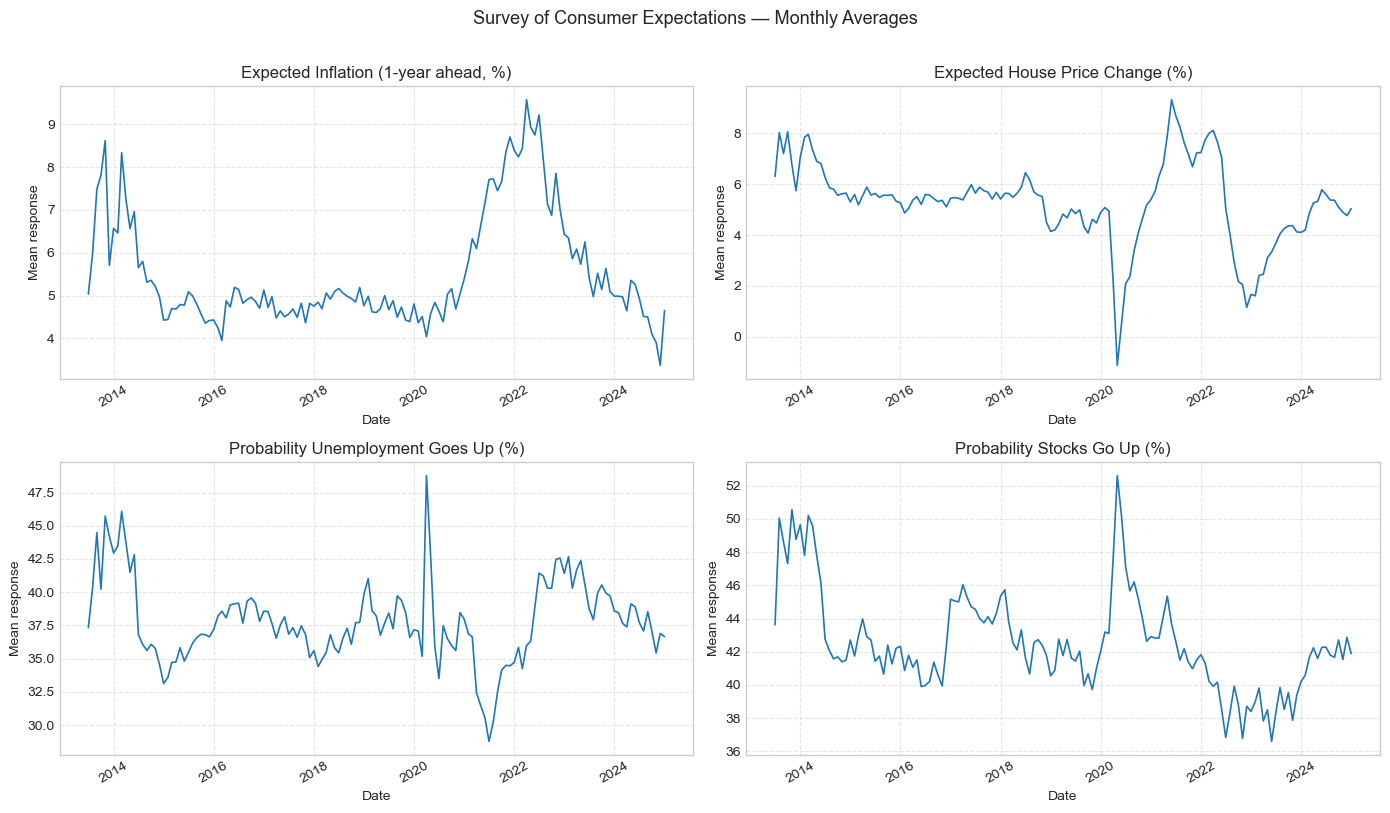

In [239]:
# Step 2 - Time series plots of the key expectation variables (monthly averages) to visualize trends and cycles
# Compute monthly means for the expectation variables using the month-end date key (date_me) to group by month
monthly_means = (
    sce_data
    .groupby(pd.Grouper(key='date', freq='ME'))[COLS_EXPECTATIONS]
    .mean()
)

# Create a 2x2 grid of subplots for the expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Loop through the variables and create time series plots (Variables and titles defined in the previous step as plot_vars)
for ax, (col, title) in zip(axes.flat, exp_plot_vars):
    ax.plot(monthly_means.index, monthly_means[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel('Mean response')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.5)

# Final adjustments and show the plot

fig.suptitle('Survey of Consumer Expectations — Monthly Averages', fontsize=13, y=1.01)
_ = plt.tight_layout()

Skriv tekst her

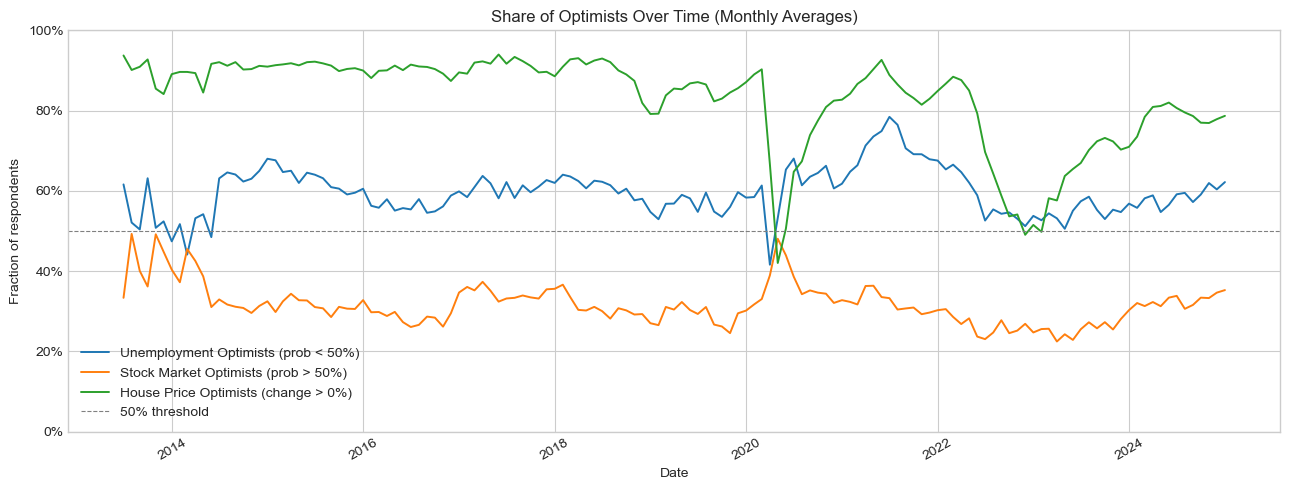

In [241]:
# Step 3 - Plot the share of optimists over time (monthly averages) to visualize trends and cycles in optimism
# Compute monthly means of the optimism indicators (performed on sce as macro/finance in sce_data is not needed here - computational efficiency)
optimism_means = (
    sce
    .groupby(pd.Grouper(key='date', freq='ME'))[OPTIMISM_COLS]
    .mean()
)

# Initialize the plot
fig, ax = plt.subplots(figsize=(13, 5))

# Plot each optimism indicator over time
for col, title in opt_plot_vars:
    ax.plot(optimism_means.index, optimism_means[col], linewidth=1.4, label=title)

# Format y-axis as percentages, set limits, add a horizontal line at 50%, and finalize the plot
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='50% threshold')
ax.set_xlabel('Date')
ax.set_ylabel('Fraction of respondents')
ax.set_title('Share of Optimists Over Time (Monthly Averages)')
ax.legend()
ax.tick_params(axis='x', rotation=30)

_ = plt.tight_layout()

Skriv tekst her

In [ ]:
# Desc stats
...

## Part 4 - Exploratory Data Analysis (Macro/Finance)

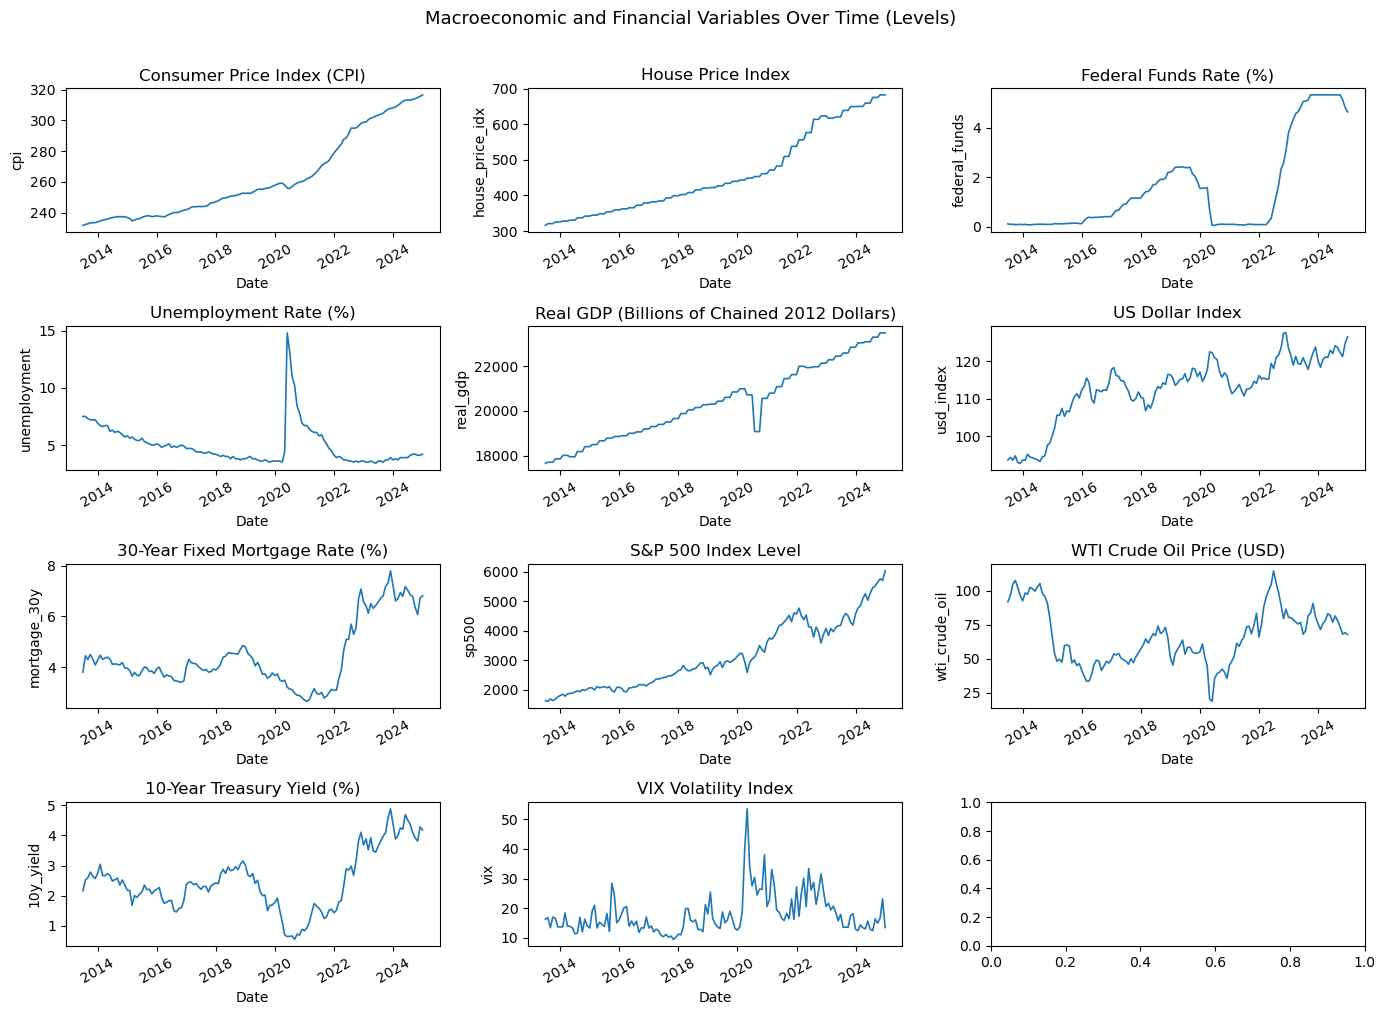

In [103]:
# Step 1 - Plot macro/finance variables in levels over time
# Variables to plot with their corresponding titles
macro_vars = [
    ('cpi', 'Consumer Price Index (CPI)'),
    ('house_price_idx', 'House Price Index'),
    ('federal_funds', 'Federal Funds Rate (%)'),
    ('unemployment', 'Unemployment Rate (%)'),
    ('real_gdp', 'Real GDP (Billions of Chained 2012 Dollars)'),
    ('usd_index', 'US Dollar Index'),
    ('mortgage_30y', '30-Year Fixed Mortgage Rate (%)'),
    ('sp500', 'S&P 500 Index Level'),
    ('wti_crude_oil', 'WTI Crude Oil Price (USD)'),
    ('10y_yield', '10-Year Treasury Yield (%)'),
    ('vix', 'VIX Volatility Index'),
]

# Initialize a 3x3 grid of subplots for the macro/finance variables
fig, axes = plt.subplots(4, 3, figsize=(14, 10))

# Loop through the macro and finance variables and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=30)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variables Over Time (Levels)', fontsize=13, y=1.01)
_ = plt.tight_layout()

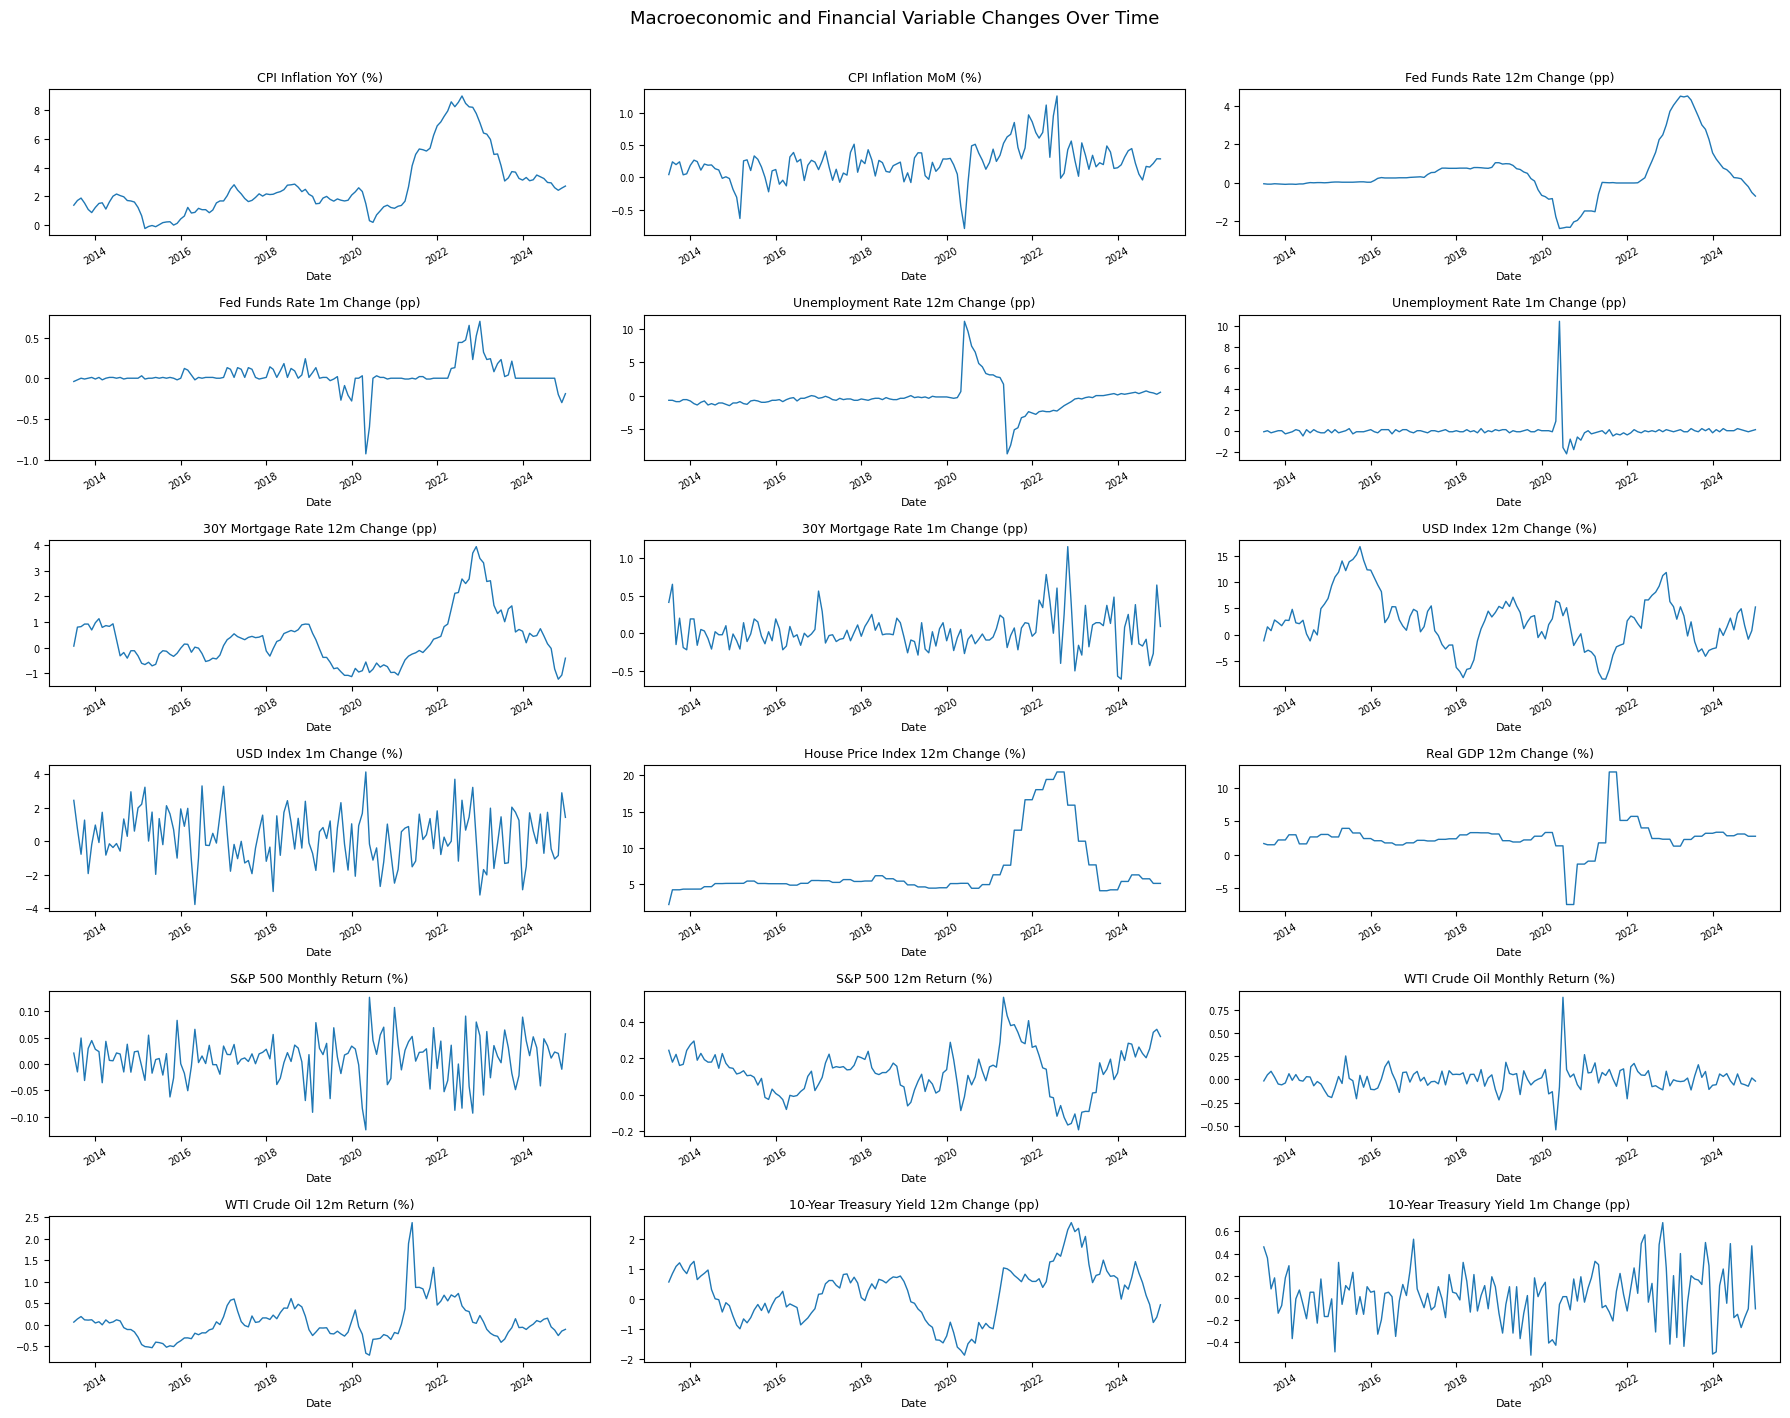

In [ ]:
# Step 2 - Plot macro/finance variables in relative/absolute changes over time
# Variables to plot with their corresponding titles (Defined as 12-month and 1-month changes in the previous steps)
macro_vars_changes = [
    ('cpi_chg12m',             'CPI Inflation YoY (%)'),
    ('cpi_chg1m',              'CPI Inflation MoM (%)'),
    ('federal_funds_chg12m',   'Fed Funds Rate 12m Change (pp)'),
    ('federal_funds_chg1m',    'Fed Funds Rate 1m Change (pp)'),
    ('unemployment_chg12m',    'Unemployment Rate 12m Change (pp)'),
    ('unemployment_chg1m',     'Unemployment Rate 1m Change (pp)'),
    ('mortgage_30y_chg12m',    '30Y Mortgage Rate 12m Change (pp)'),
    ('mortgage_30y_chg1m',     '30Y Mortgage Rate 1m Change (pp)'),
    ('usd_index_chg12m',       'USD Index 12m Change (%)'),
    ('usd_index_chg1m',        'USD Index 1m Change (%)'),
    ('house_price_idx_chg12m', 'House Price Index 12m Change (%)'),
    ('real_gdp_chg12m',        'Real GDP 12m Change (%)'),
    ('sp500_chg',              'S&P 500 Monthly Return (%)'),
    ('sp500_chg_12m',          'S&P 500 12m Return (%)'),
    ('wti_crude_oil_chg',      'WTI Crude Oil Monthly Return (%)'),
    ('wti_crude_oil_chg_12m',  'WTI Crude Oil 12m Return (%)'),
    ('10y_yield_chg12m',   '10-Year Treasury Yield 12m Change (pp)'),
    ('10y_yield_chg1m',    '10-Year Treasury Yield 1m Change (pp)')
]

# Initialize a 6x3 grid of subplots for the macro/finance variables in changes
fig, axes = plt.subplots(6, 3, figsize=(18, 14))

# Loop through the macro and finance variables in changes and plot each one in a separate subplot
for ax, (col, title) in zip(axes.flat, macro_vars_changes):
    ax.plot(macro_all.index, macro_all[col], linewidth=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Date', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

# Final adjustments and show the plot
fig.suptitle('Macroeconomic and Financial Variable Changes Over Time', fontsize=13, y=1.01)
_ = plt.tight_layout()

In [105]:
# Step 3 - Correlation between macro/finance variables and expectations variables
MACRO_COLS = [c for c in sce_data.columns if c not in
              set(COLS_META + COLS_EXPECTATIONS + COLS_FIRST_WAVE + COLS_INDIVIDUAL +
                  OPTIMISM_COLS)]

for target in COLS_EXPECTATIONS:
    corr = (
        sce_data[MACRO_COLS]
        .corrwith(sce_data[target])
        .rename('correlation')
        .to_frame()
        .assign(abs_corr=lambda df: df['correlation'].abs())
        .sort_values('abs_corr', ascending=False)
        .drop(columns='abs_corr')
    )
    print(f"\nCorrelations with {target}:")
    display(corr)


Correlations with infl_1y:


,correlation
house_price_idx_chg12m,0.125697
cpi_chg12m,0.118191
cpi_chg1m,0.091943
wti_crude_oil_ret_12m,0.088985
wti_crude_oil,0.087772
10y_yield_chg12m,0.077074
mortgage_30y_chg12m,0.072578
unemployment_chg12m,-0.061506
sp500,0.058356
house_price_idx,0.052536



Correlations with house_price_change:


,correlation
sp500_ret_12m,0.132420
wti_crude_oil_ret_12m,0.108881
unemployment_chg12m,-0.102888
usd_index,-0.092969
federal_funds,-0.079678
mortgage_30y,-0.076504
real_gdp_chg12m,0.074175
vix,-0.070493
cpi_chg1m,0.069073
usd_index_chg12m,-0.061971



Correlations with prob_unrate_up:


,correlation
sp500_ret_12m,-0.079531
mortgage_30y_chg12m,0.056567
mortgage_30y,0.056489
federal_funds_chg12m,0.052331
federal_funds,0.048801
10y_yield,0.043033
wti_crude_oil_ret_12m,-0.042259
usd_index,0.039868
unemployment,-0.037584
usd_index_chg12m,0.034683



Correlations with prob_stocks_up:


,correlation
federal_funds_chg12m,-0.069023
unemployment,0.058369
federal_funds_chg1m,-0.055404
cpi_chg12m,-0.054776
mortgage_30y_chg12m,-0.054080
mortgage_30y,-0.051318
cpi,-0.049425
10y_yield,-0.049115
house_price_idx,-0.049035
wti_crude_oil,-0.047962


## Part 5 - Predicting Continous Expectation Variables

In [ ]:
# Choose Macro/Finance variables as predictors 
MACRO_PREDS = ['house_price_idx_chg12m', 'cpi_chg12m', 'wti_crude_oil_chg_12m', 'unemployment_chg12m', '10y_yield_chg12m']

# Choose SCE predictors for step 2

# If categorical variable, use one-hot encoding (Shoul)

# List of unique categories
educ_uniq = list(np.sort(sce_data['educ'].unique()))

# Create dummy variable encoder

enc = OneHotEncoder(categories=[educ_uniq], sparse_output=False)

# Convert string variable into binary indicator variables
educ_dummies = enc.fit_transform(sce_data[['educ']])
SCE_PREDS = ['age_init', 'educ', 'female', 'hh_inc_bin_rank', 'working', 'owner']

ALL_PREDS = MACRO_PREDS + SCE_PREDS

In [107]:
ridge_alphas = np.logspace(np.log10(1e-5), np.log10(5), 100)
lasso_alphas = np.logspace(np.log10(1e-4), np.log10(1), 50)

In [108]:
ridge = RidgeCV(
    alphas=np.logspace(-3, 4, 50),
    cv=None,              # LOO CV
    # some versions ignore or don’t expose cv_values_
)

lasso = LassoCV(
    alphas=np.logspace(-3, 2, 50),
    cv=5,
    random_state=0,
)

MODELS = {
    "OLS":   make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), ridge),
    "Lasso": make_pipeline(StandardScaler(), lasso),
}

In [109]:
def plot_ts_all_models(dates_train, y_train,
                       dates_test,  y_test,
                       preds_train, preds_test,
                       target_name, feature_set_name,
                       split_date="2024-01-01"):
    """
    Plot monthly-averaged actual and predicted (OLS, Ridge, Lasso) in one panel.
    preds_train/test is a dict: {'OLS': y_hat, 'Ridge': y_hat, 'Lasso': y_hat}
    """

    # Build long DataFrame: one row per obs × model
    def build_df(dates, y, preds, sample_label):
        rows = []
        for model_name, y_hat in preds.items():
            rows.append(pd.DataFrame({
                "date": dates.values,
                "actual": np.asarray(y),
                "predicted": np.asarray(y_hat),
                "model": model_name,
                "sample": sample_label,
            }))
        return pd.concat(rows, ignore_index=True)

    df_all = pd.concat([
        build_df(dates_train, y_train, preds_train, "train"),
        build_df(dates_test,  y_test,  preds_test,  "test"),
    ], ignore_index=True)

    # Monthly averages
    df_all["month"] = pd.to_datetime(df_all["date"]).dt.to_period("M").dt.to_timestamp()
    df_month = (
        df_all
        .groupby(["month", "model"])[["actual", "predicted"]]
        .mean()
        .reset_index()
    )

    # Plot
    plt.figure(figsize=(10, 4))

    # Actual series: same for all models → take one group
    df_actual = df_month[df_month["model"] == "OLS"]  # arbitrary model
    plt.plot(df_actual["month"], df_actual["actual"],
             label="Actual", color="black", linewidth=2)

    # Predicted series per model
    colors = {"OLS": "tab:purple", "Ridge": "darkorange", "Lasso": "tab:green"}
    for model_name in ["OLS", "Ridge", "Lasso"]:
        df_m = df_month[df_month["model"] == model_name]
        plt.plot(df_m["month"], df_m["predicted"],
                 label=model_name, color=colors[model_name], linestyle="--")

    plt.axvline(pd.Timestamp(split_date), color="red", linestyle=":",
                label="Train/Test split")
    plt.xlabel("Date")
    plt.ylabel(target_name)
    plt.title(f"{target_name} — {feature_set_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [110]:
def ridge_cv_and_validation_curve(X_train, y_train, target_name, feature_set_name):
    """
    Run RidgeCV (no pipeline), plot validation curve using cv_results_,
    and return alpha_best.
    """

    # Standardize features first (like in lecture 11)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)

    rcv = RidgeCV(
        alphas=ridge_alphas,
        store_cv_results=True,  # lecture: cv_results_ of shape (Nobs, Nalphas)
        cv=None,                # leave-one-out
    ).fit(X_tr, y_train)

    alpha_best = rcv.alpha_
    mse_mean   = np.mean(rcv.cv_results_, axis=0)
    imin       = np.argmin(mse_mean)

    plt.figure(figsize=(6, 4))
    plt.plot(ridge_alphas, mse_mean)
    plt.scatter(ridge_alphas[imin], mse_mean[imin], s=15, c="black", zorder=100)
    plt.axvline(ridge_alphas[imin], ls=":", lw=0.75, c="black")
    plt.xscale("log")
    plt.xlabel(r"Regularization strength $\alpha$ (log scale)")
    plt.ylabel("Cross-validated MSE")
    plt.title(f"Ridge validation curve — {target_name} ({feature_set_name})")
    plt.tight_layout()
    plt.show()

    print(f"Ridge best alpha for {target_name} [{feature_set_name}]: {alpha_best:.4g}")

    return alpha_best

In [111]:
def lasso_cv_and_validation_curve(X_train, y_train, target_name, feature_set_name):
    """
    Run LassoCV inside a pipeline, plot validation curve using mse_path_,
    and return the fitted pipeline.
    """
    pipe_lasso = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=lasso_alphas, cv=5, random_state=0)
    )
    pipe_lasso.fit(X_train, y_train)

    est = pipe_lasso.named_steps["lassocv"]
    mse = est.mse_path_.mean(axis=1)   # mean over folds
    alphas = est.alphas_
    alpha_best = est.alpha_

    plt.figure(figsize=(6, 4))
    plt.semilogx(alphas, mse, marker="o", markersize=3)
    plt.axvline(alpha_best, color="red", linestyle="--",
                label=f"Best alpha = {alpha_best:.4f}")
    plt.xlabel("alpha")
    plt.ylabel("CV MSE")
    plt.title(f"Lasso validation curve — {target_name} ({feature_set_name})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Lasso best alpha for {target_name} [{feature_set_name}]: {alpha_best:.4g}")

    return pipe_lasso

In [112]:
FEATURE_SETS = {
    "Macro only":  MACRO_PREDS,
    "Macro + SCE": ALL_PREDS,
}

TARGETS = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

dates_train_mask = sce_data["date"].dt.year < 2024
dates_test_mask  = sce_data["date"].dt.year == 2024

train = sce_data[dates_train_mask].copy()
test  = sce_data[dates_test_mask].copy()

X_train_full = train[ALL_PREDS]
y_train_full = train[TARGETS]
X_test_full  = test[ALL_PREDS]
y_test_full  = test[TARGETS]

dates_train = train["date"]
dates_test  = test["date"]


----------------------------------------------------------------------
infl_1y | Macro only
----------------------------------------------------------------------


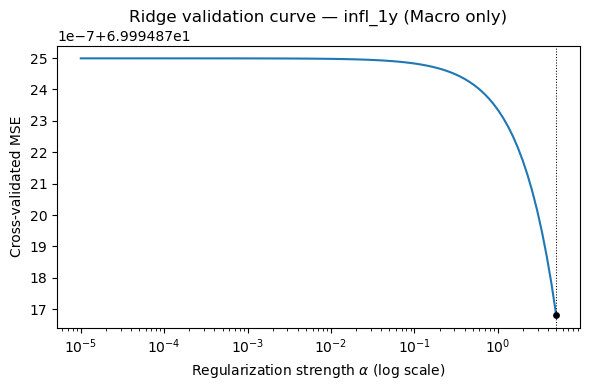

Ridge best alpha for infl_1y [Macro only]: 5


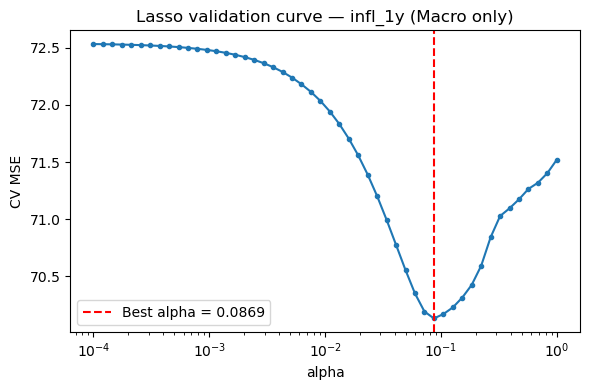

Lasso best alpha for infl_1y [Macro only]: 0.08685


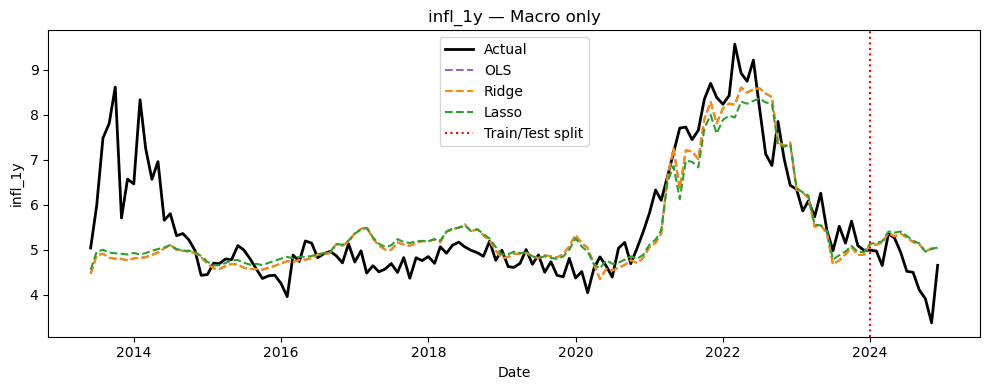


----------------------------------------------------------------------
infl_1y | Macro + SCE
----------------------------------------------------------------------


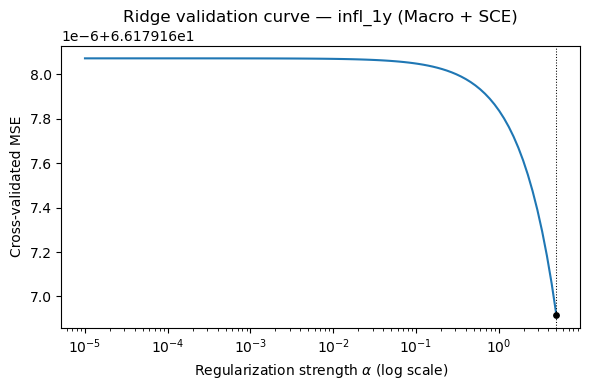

Ridge best alpha for infl_1y [Macro + SCE]: 5


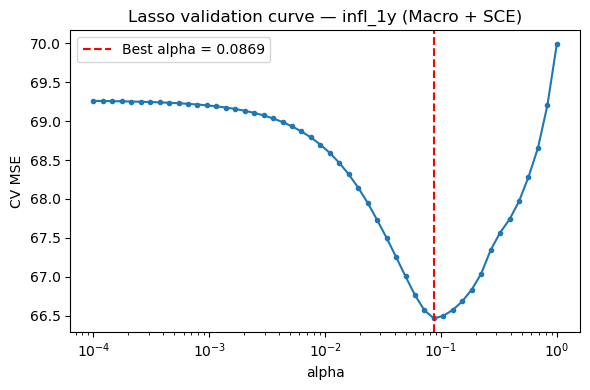

Lasso best alpha for infl_1y [Macro + SCE]: 0.08685


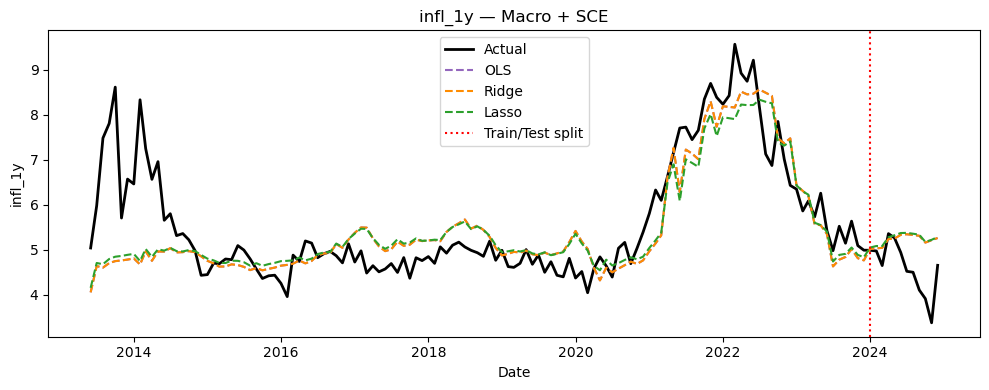


----------------------------------------------------------------------
house_price_change | Macro only
----------------------------------------------------------------------


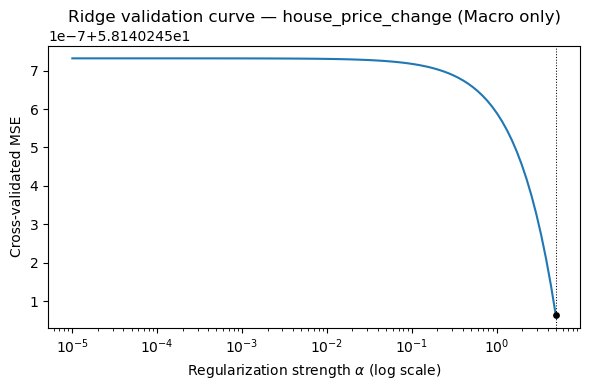

Ridge best alpha for house_price_change [Macro only]: 5


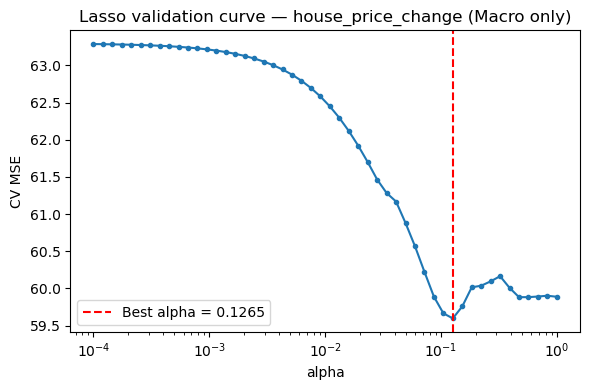

Lasso best alpha for house_price_change [Macro only]: 0.1265


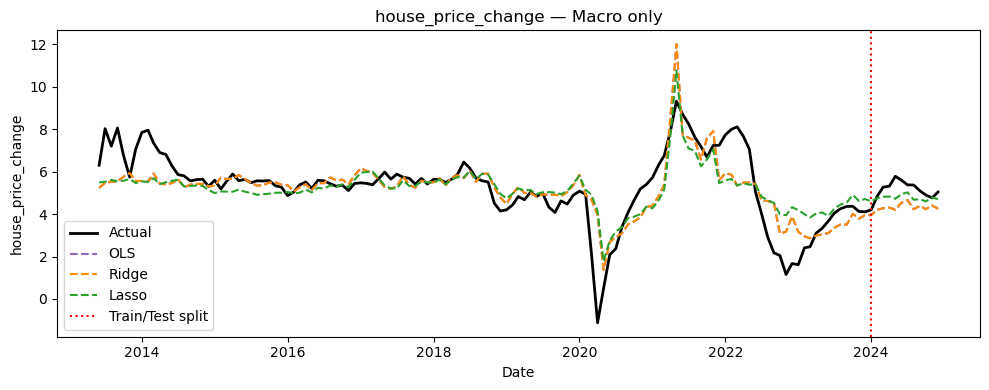


----------------------------------------------------------------------
house_price_change | Macro + SCE
----------------------------------------------------------------------


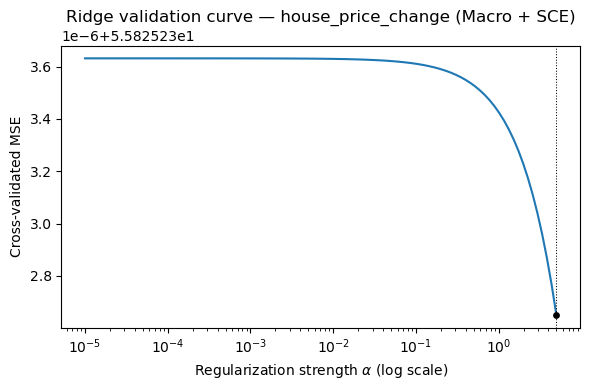

Ridge best alpha for house_price_change [Macro + SCE]: 5


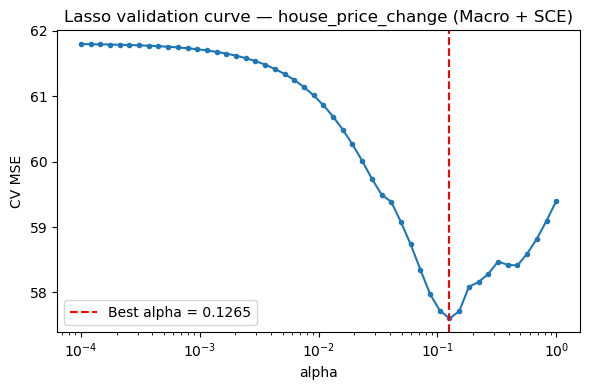

Lasso best alpha for house_price_change [Macro + SCE]: 0.1265


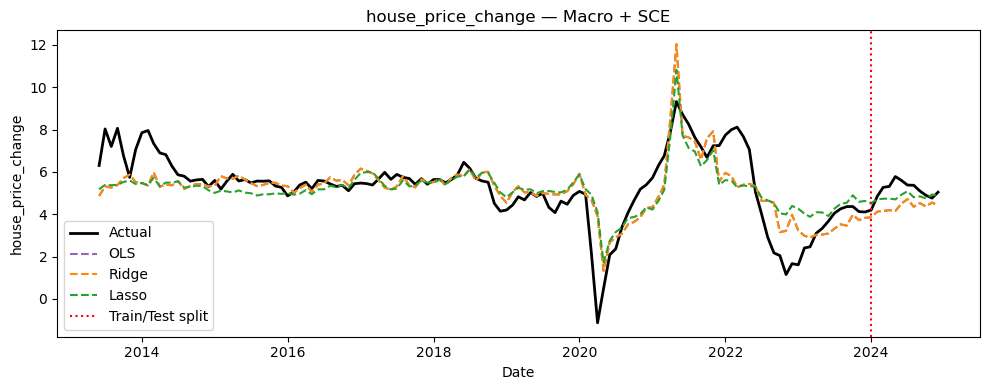


----------------------------------------------------------------------
prob_unrate_up | Macro only
----------------------------------------------------------------------


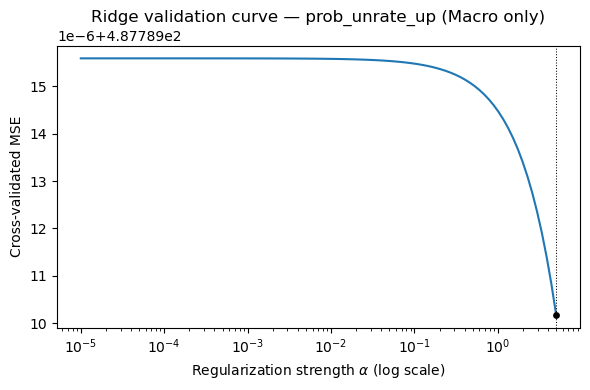

Ridge best alpha for prob_unrate_up [Macro only]: 5


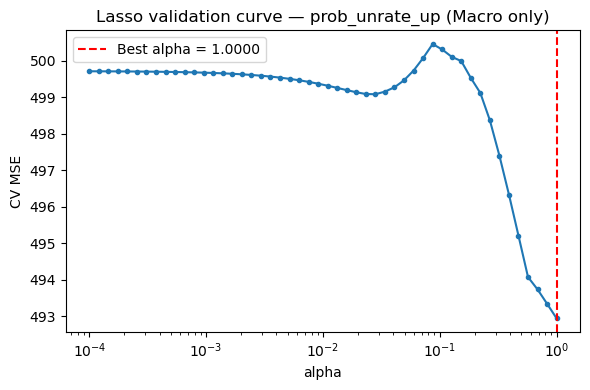

Lasso best alpha for prob_unrate_up [Macro only]: 1


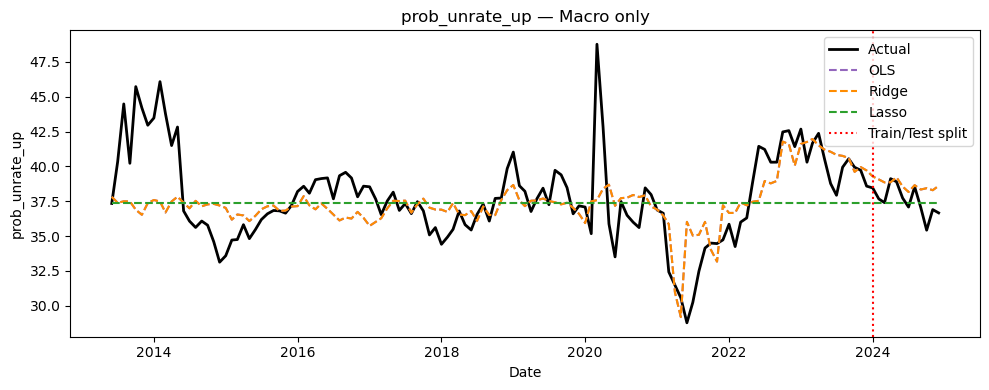


----------------------------------------------------------------------
prob_unrate_up | Macro + SCE
----------------------------------------------------------------------


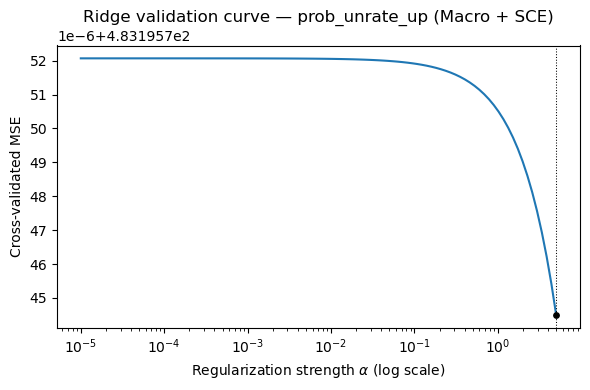

Ridge best alpha for prob_unrate_up [Macro + SCE]: 5


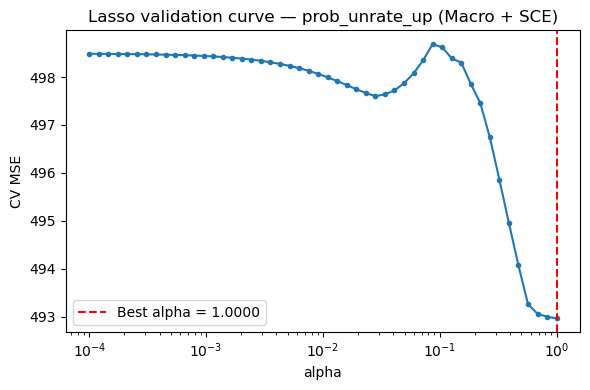

Lasso best alpha for prob_unrate_up [Macro + SCE]: 1


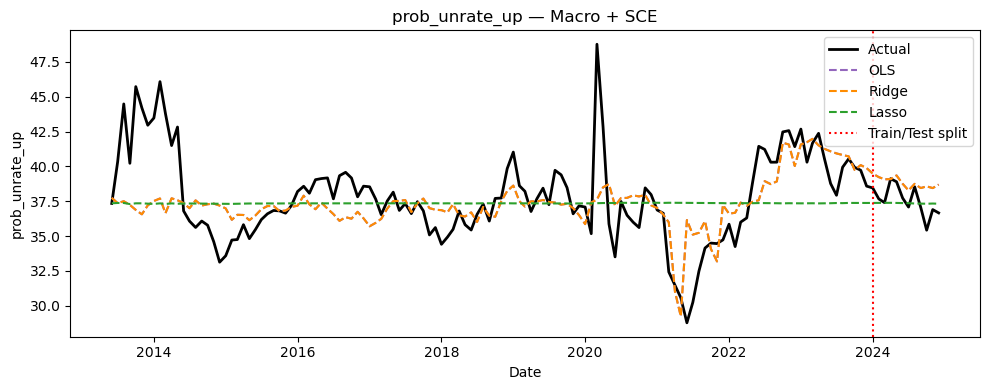


----------------------------------------------------------------------
prob_stocks_up | Macro only
----------------------------------------------------------------------


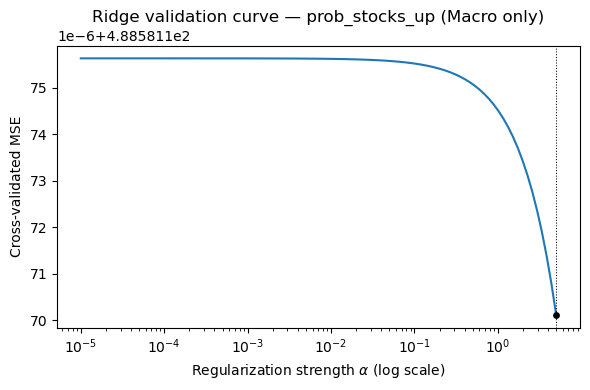

Ridge best alpha for prob_stocks_up [Macro only]: 5


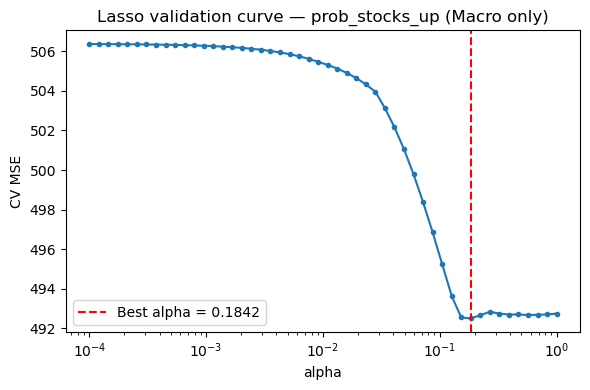

Lasso best alpha for prob_stocks_up [Macro only]: 0.1842


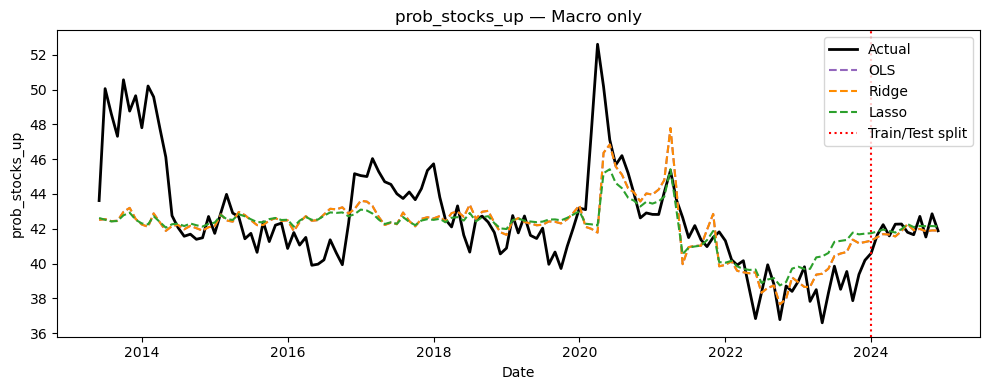


----------------------------------------------------------------------
prob_stocks_up | Macro + SCE
----------------------------------------------------------------------


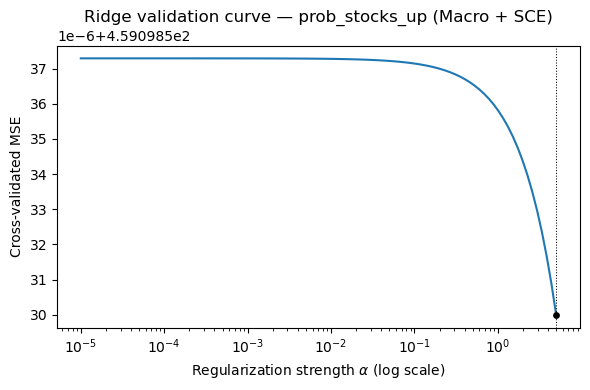

Ridge best alpha for prob_stocks_up [Macro + SCE]: 5


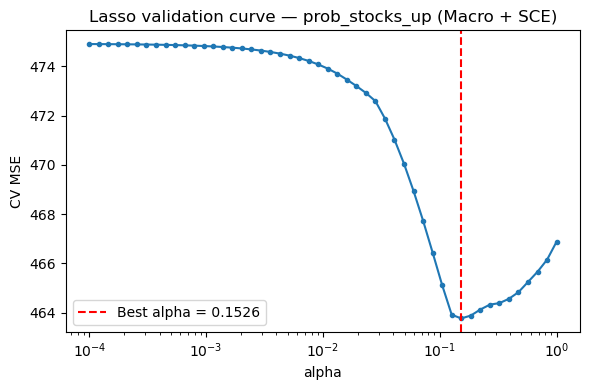

Lasso best alpha for prob_stocks_up [Macro + SCE]: 0.1526


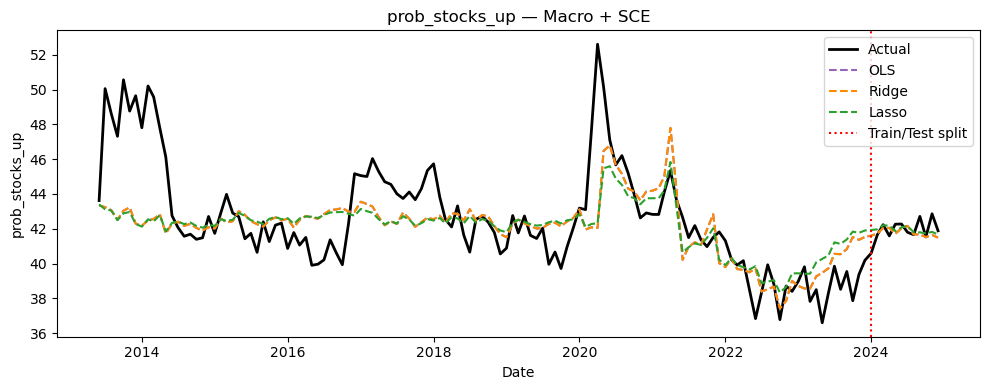

In [113]:
all_metrics = []

for target in TARGETS:
    for fs_name, features in FEATURE_SETS.items():
        print("\n" + "-" * 70)
        print(f"{target} | {fs_name}")
        print("-" * 70)

        X_tr = X_train_full[features]
        X_te = X_test_full[features]
        y_tr = y_train_full[target]
        y_te = y_test_full[target]

        # 1) OLS pipeline (simple)
        pipe_ols = make_pipeline(StandardScaler(), LinearRegression())
        pipe_ols.fit(X_tr, y_tr)

        # 2) Ridge: first RidgeCV for validation curve & alpha_best
        alpha_best_ridge = ridge_cv_and_validation_curve(X_tr, y_tr, target, fs_name)

        #    then pipeline with Ridge(alpha_best_ridge)
        pipe_ridge = make_pipeline(StandardScaler(),
                                   Ridge(alpha=alpha_best_ridge, fit_intercept=True))
        pipe_ridge.fit(X_tr, y_tr)

        # 3) Lasso: CV + validation curve + fitted pipeline
        pipe_lasso = lasso_cv_and_validation_curve(X_tr, y_tr, target, fs_name)

        # ---- Predictions on train/test for all three models ----
        yhat_tr = {
            "OLS":   pipe_ols.predict(X_tr),
            "Ridge": pipe_ridge.predict(X_tr),
            "Lasso": pipe_lasso.predict(X_tr),
        }
        yhat_te = {
            "OLS":   pipe_ols.predict(X_te),
            "Ridge": pipe_ridge.predict(X_te),
            "Lasso": pipe_lasso.predict(X_te),
        }

        # Time-series plot (all models in one panel)
        plot_ts_all_models(
            dates_train, y_tr,
            dates_test,  y_te,
            yhat_tr, yhat_te,
            target_name=target,
            feature_set_name=fs_name,
            split_date="2024-01-01",
        )

        # Metrics on test set
        for model_name, y_pred in yhat_te.items():
            rmse = np.sqrt(mean_squared_error(y_te, y_pred))
            r2   = r2_score(y_te, y_pred)
            all_metrics.append({
                "target": target,
                "feature_set": fs_name,
                "model": model_name,
                "RMSE": rmse,
                "R2": r2,
            })

In [114]:
results_df = pd.DataFrame(all_metrics)
results_df

,target,feature_set,model,RMSE,R2
0,infl_1y,Macro only,OLS,9.243671,-0.002665
1,infl_1y,Macro only,Ridge,9.243674,-0.002666
2,infl_1y,Macro only,Lasso,9.244639,-0.002875
3,infl_1y,Macro + SCE,OLS,9.045591,0.039846
4,infl_1y,Macro + SCE,Ridge,9.045595,0.039845
5,infl_1y,Macro + SCE,Lasso,9.048028,0.039328
6,house_price_change,Macro only,OLS,8.477441,-0.008942
7,house_price_change,Macro only,Ridge,8.477419,-0.008937
8,house_price_change,Macro only,Lasso,8.445451,-0.001342
9,house_price_change,Macro + SCE,OLS,8.324366,0.027165


In [ ]:
def fit_and_evaluate(
    model,
    X_train, X_test,
    y_train, y_test,
    dates_train, dates_test,
    target_name,
    model_name,
    feature_set_name,
    split_date="2024-01-01",
):
    """
    Fit model, optionally plot validation curve,
    plot actual vs predicted over time, and return RMSE and R² on the test set.
    """

    # 1. Fit
    model.fit(X_train, y_train)

    # 2. Print optimal alpha if Ridge/Lasso
    estimator = model.named_steps[list(model.named_steps.keys())[-1]]
    if hasattr(estimator, "alpha_"):
        print(f"{model_name} — {feature_set_name} — {target_name}: "
              f"best alpha = {estimator.alpha_:.4f}")

    # 3. Validation curve (Lasso only in our helper)
    plot_validation_curve(model, target_name)

    # 4. Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    # 5. Monthly average time series plot
    df_train = pd.DataFrame({
        "date": dates_train,
        "actual": y_train,
        "predicted": y_pred_train,
    })
    df_test = pd.DataFrame({
        "date": dates_test,
        "actual": y_test,
        "predicted": y_pred_test,
    })

    def monthly_avg(df):
        df = df.copy()
        df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").dt.to_timestamp()
        return df.groupby("month")[["actual", "predicted"]].mean()

    combined = pd.concat([monthly_avg(df_train), monthly_avg(df_test)]).sort_index()

    plt.figure(figsize=(10, 4))
    plt.plot(combined.index, combined["actual"], label="Actual", color="black")
    plt.plot(combined.index, combined["predicted"], label="Predicted",
             color="steelblue", linestyle="--")
    plt.axvline(pd.Timestamp(split_date), color="red", linestyle=":",
                label="Train/Test split")
    plt.xlabel("Date")
    plt.ylabel(target_name)
    plt.title(f"{target_name} — {model_name} — {feature_set_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 6. Test metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    print(f"Test RMSE = {rmse:.4f}, R² = {r2:.4f}")

    return {
        "target": target_name,
        "model": model_name,
        "feature_set": feature_set_name,
        "RMSE": rmse,
        "R2": r2,
    }

In [ ]:
FEATURE_SETS = {
    "Macro only":  MACRO_PREDS,  # list of column names
    "Macro + SCE": ALL_PREDS,    # list of column names
}

TARGETS = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

dates_train_mask = sce_data["date"].dt.year < 2024
dates_test_mask  = sce_data["date"].dt.year == 2024

train = sce_data[dates_train_mask].copy()
test  = sce_data[dates_test_mask].copy()

X_train = train[ALL_PREDS]
y_train = train[TARGETS]
X_test  = test[ALL_PREDS]
y_test  = test[TARGETS]

dates_train = train["date"]
dates_test  = test["date"]

In [ ]:
all_metrics = []

for target in TARGETS:
    for fs_name, features in FEATURE_SETS.items():
        for model_name, model_template in MODELS.items():
            print("\n" + "-" * 60)
            print(f"{target} | {model_name} | {fs_name}")
            print("-" * 60)

            metrics = fit_and_evaluate(
                model        = clone(model_template),
                X_train      = X_train[features],
                X_test       = X_test[features],
                y_train      = y_train[target],
                y_test       = y_test[target],
                dates_train  = dates_train,
                dates_test   = dates_test,
                target_name  = target,
                model_name   = model_name,
                feature_set_name = fs_name,
            )
            all_metrics.append(metrics)

results_df = pd.DataFrame(all_metrics)
results_df

## Part 6 - Predicting Binary Optimism Variables (Classification)

## Part 7 - Conclusion